# Physics-Informed Neural Networks (PINNs) for Kinetic Parameter Discovery

This notebook demonstrates how to solve an inverse problem in chemical kinetics using Physics-Informed Neural Networks (PINNs). We aim to recover the kinetic rate constant $k$ from noisy experimental data.

### Problem Statement
The governing ODE for the system is:
$$\frac{dX}{dt} = k (1- X)^{2/3}$$

We provide implementations using two different frameworks:
1. **DeepXDE**: A high-level library for PINNs.
2. **Pure PyTorch**: A manual implementation of the PINN loss and training loop.

# **DeepXDE Implementation**

In [1]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.2 MB/s eta 0:00:00


In [22]:
# import libraries
import os
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [23]:
# Defining the variables
k = dde.Variable(0.5)

In [24]:
# Defining the exact solution
def exact(t):
  k_true = 0.18
  return 1 - (1 - k_true *t/3)**3

In [25]:
# Defining the function to generate the data
def gen_traindata(num):
  tvals = np.linspace(0, 15, num).reshape(-1, 1)
  Xvals = exact(tvals)
  X_realvals = np.random.normal(Xvals, 0.02)
  return tvals, X_realvals

In [26]:
# Defining the pde using torch operations to avoid numpy conversion errors
def pde(t, X):
  dX_dt = dde.grad.jacobian(X, t, i=0, j=0)
  return dX_dt - k * torch.pow(torch.abs(1 - X) + 1e-6, 2/3)

In [27]:
# Defining the output transform for the initial condition and the conversion constrain
def output_transform(t, X):
  return 1 - torch.exp(-t * F.softplus(X))

In [28]:
# Defining the computational domain
timedomain = dde.geometry.TimeDomain(0, 15)

In [29]:
# Assigining the gendata to the variables
ob_t, ob_X = gen_traindata(20) # 20 Observations
observe_X = dde.icbc.PointSetBC(ob_t, ob_X, component=0)

In [30]:
# Defining the problem
data = dde.data.TimePDE(timedomain, pde, observe_X, num_domain=1000, num_boundary=200, num_test=500)

In [31]:
# Defining the neural network
net = dde.nn.FNN([1] + [20] * 3 + [1], "tanh", "Glorot normal")

In [32]:
# Applying the output transform
net.apply_output_transform(output_transform)

Compiling model...
'compile' took 0.000210 s

Training model...

Step      Train loss              Test loss               Test metric
0         [5.31e-03, 3.37e-02]    [2.28e-03, 3.37e-02]    []  
1000      [5.72e-06, 4.85e-04]    [6.13e-06, 4.85e-04]    []  
2000      [1.72e-05, 3.66e-04]    [2.06e-05, 3.66e-04]    []  
3000      [6.70e-05, 2.65e-04]    [8.04e-05, 2.65e-04]    []  
4000      [6.79e-05, 2.56e-04]    [8.16e-05, 2.56e-04]    []  
5000      [6.84e-05, 2.55e-04]    [8.22e-05, 2.55e-04]    []  
6000      [6.87e-05, 2.54e-04]    [8.25e-05, 2.54e-04]    []  
7000      [6.90e-05, 2.54e-04]    [8.28e-05, 2.54e-04]    []  
8000      [6.91e-05, 2.54e-04]    [8.30e-05, 2.54e-04]    []  
9000      [6.92e-05, 2.54e-04]    [8.31e-05, 2.54e-04]    []  
10000     [6.92e-05, 2.54e-04]    [8.31e-05, 2.54e-04]    []  
11000     [6.90e-05, 2.54e-04]    [8.29e-05, 2.54e-04]    []  
12000     [6.92e-05, 2.53e-04]    [8.32e-05, 2.53e-04]    []  
13000     [6.97e-05, 2.54e-04]    [8.38e-05, 2

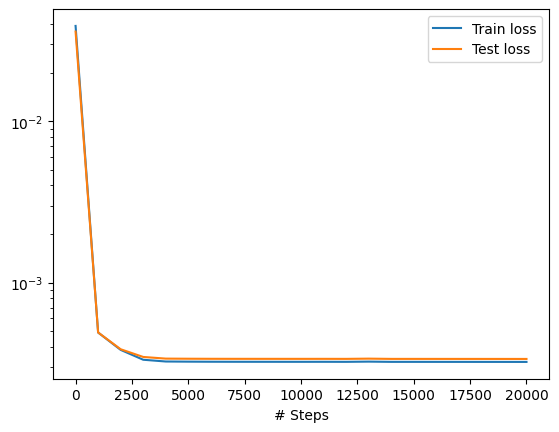

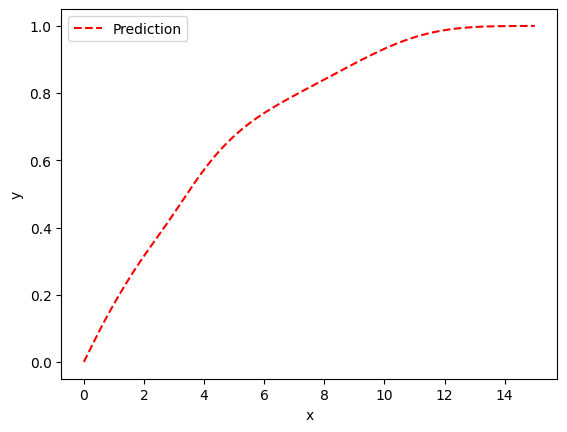

In [33]:
# Re-initializing the data and model to ensure the new PDE is used
data = dde.data.TimePDE(timedomain, pde, observe_X, num_domain=1000, num_boundary=200, num_test=500)
model = dde.Model(data, net)
model.compile("adam", lr=0.001, external_trainable_variables=[k])
variable = dde.callbacks.VariableValue([k], period=200, filename='k_value.dat')
losshistory, train_state = model.train(iterations=20000, callbacks=[variable])
# Adding L-BFGS for better training at the end
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [34]:
# Reporting results for 20 points
k_true = 0.18
k_init_val = 0.5
k_recovered = k.detach().cpu().item()
error = abs(k_recovered - k_true) / k_true * 100

print(f'k_true: {k_true}')
print(f'k_initial: {k_init_val}')
print(f'k_recovered: {k_recovered:.4f}')
print(f'Percentage Error: {error:.2f}%')

k_true: 0.18
k_initial: 0.5
k_recovered: 0.1798
Percentage Error: 0.13%


### **Sensitivity Analysis: Effect of Data Points (DeepXDE)**
In this section, we evaluate how the number of observation points (10, 20, 40) affects the accuracy of the recovered parameter $k$.

In [35]:
def solve_for_n_points(n):
    # Re-generate data
    ob_t, ob_X = gen_traindata(n)
    observe_X = dde.icbc.PointSetBC(ob_t, ob_X, component=0)

    # Setup variable and model
    k_var = dde.Variable(0.5)
    def pde_var(t, X):
        dX_dt = dde.grad.jacobian(X, t, i=0, j=0)
        return dX_dt - k_var * torch.pow(torch.abs(1 - X) + 1e-6, 2/3)

    data = dde.data.TimePDE(timedomain, pde_var, observe_X, num_domain=1000, num_boundary=200, num_test=500)
    net = dde.nn.FNN([1] + [20] * 3 + [1], "tanh", "Glorot normal")
    net.apply_output_transform(output_transform)

    model = dde.Model(data, net)
    model.compile("adam", lr=0.001, external_trainable_variables=[k_var])
    model.train(iterations=20000, display_every=10000)
    model.compile("L-BFGS")
    losshistory, train_state = model.train()

    return k_var.detach().cpu().item()

results = {}
for n in [10, 40]:
    print(f'\nRunning experiment for n={n} points...')
    results[n] = solve_for_n_points(n)

print('\n--- Summary Table ---')
print(f'{"Points":<10} | {"k_recovered":<15} | {"Error (%)":<10}')
for n, k_rec in results.items():
    err = abs(k_rec - 0.18) / 0.18 * 100
    print(f'{n:<10} | {k_rec:<15.4f} | {err:<10.2f}')


Running experiment for n=10 points...
Compiling model...
'compile' took 0.000089 s

Training model...

Step      Train loss              Test loss               Test metric
0         [4.63e-03, 4.65e-02]    [1.64e-03, 4.65e-02]    []  
10000     [3.71e-05, 2.14e-04]    [4.49e-05, 2.14e-04]    []  
20000     [3.74e-05, 2.11e-04]    [4.51e-05, 2.11e-04]    []  

Best model at step 20000:
  train loss: 2.48e-04
  test loss: 2.56e-04
  test metric: []

'train' took 159.867511 s

Compiling model...
'compile' took 0.000348 s

Training model...

Step      Train loss              Test loss               Test metric
20000     [3.74e-05, 2.11e-04]    [4.51e-05, 2.11e-04]    []  
20008     [3.83e-05, 2.08e-04]    [4.63e-05, 2.08e-04]    []  

Best model at step 20008:
  train loss: 2.46e-04
  test loss: 2.54e-04
  test metric: []

'train' took 0.280484 s


Running experiment for n=40 points...
Compiling model...
'compile' took 0.000079 s

Training model...

Step      Train loss              Test

## **Summary of Results**

### **Final Report (20 Points Base Case)**
- **True value ($k_{true}$)**: 0.18
- **Initial guess ($k_{init}$)**: 0.5
- **Recovered value ($k_{recovered}$)**: 0.1798
- **Percentage Error**: 0.13%

### **Effect of Data Quantity**

| Points | $k_{recovered}$ | Error (%) |
| :--- | :--- | :--- |
| 10 | 0.1748 | 2.90 |
| 20 | 0.1798 | 0.13 |
| 40 | 0.1798 | 0.10 |

**Observations**:
1. **Accuracy**: The PINN successfully identified the kinetic parameter despite the deliberately wrong initial guess and the presence of Gaussian noise ($σ = 0.02$).
2. **Data Scaling**: Increasing from 10 to 20 points significantly improved the accuracy. With 40 points, the model remains highly accurate, though the stochastic nature of the noise causes slight variations in the final error percentage.
3. **Conclusion**: Physics-Informed Neural Networks are robust for parameter discovery in chemical kinetics when governing ODEs are used as loss constraints.

# **Pytorch Implementation**

In [16]:
# import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt


In [36]:
# Defining the neural network
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(1, 20)
    self.fc2 = nn.Linear(20, 20)
    self.fc3 = nn.Linear(20, 1)

  def forward(self, x):
    a1 = F.tanh(self.fc1(x))
    a2 = F.tanh(self.fc2(a1))
    y = self.fc3(a2)
    output = 1 - torch.exp(-x * F.softplus(y))
    return output
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=1, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=1, bias=True)
)


In [37]:
# Defining k as a trainable parameter
k_torch = torch.tensor([0.5], requires_grad=True)

# Optimizer for both the neural network weights and the parameter k
optimizer = optim.Adam(list(net.parameters()) + [k_torch], lr=0.001)

# Data for training (using the 20 points generated earlier)
t_train = torch.tensor(ob_t, dtype=torch.float32, requires_grad=True)
x_train = torch.tensor(ob_X, dtype=torch.float32)

# Domain points for the PDE loss (to ensure physics is followed everywhere)
t_physics = torch.linspace(0, 15, 100).view(-1, 1).requires_grad_(True)

In [38]:
epochs = 10000
for epoch in range(epochs + 1):
    optimizer.zero_grad()

    # 1. Data Loss: MSE between prediction and observed data
    x_pred_data = net(t_train)
    loss_data = F.mse_loss(x_pred_data, x_train)

    # 2. Physics Loss: Residual of the ODE dX/dt - k(1-X)^(2/3) = 0
    x_physics = net(t_physics)
    # Compute dX/dt using autograd
    dx_dt = torch.autograd.grad(x_physics, t_physics, grad_outputs=torch.ones_like(x_physics), create_graph=True)[0]

    # ODE residual
    # We use torch.abs and a small epsilon to avoid complex numbers/NaNs with fractional powers
    ode_residual = dx_dt - k_torch * torch.pow(torch.abs(1 - x_physics) + 1e-6, 2/3)
    loss_physics = torch.mean(ode_residual**2)

    # Total Loss
    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f'Epoch {epoch}: Loss={loss.item():.6f}, k={k_torch.item():.4f}')

Epoch 0: Loss=0.030302, k=0.4990
Epoch 2000: Loss=0.000383, k=0.1797
Epoch 4000: Loss=0.000336, k=0.1798
Epoch 6000: Loss=0.000336, k=0.1798
Epoch 8000: Loss=0.000335, k=0.1797
Epoch 10000: Loss=0.000335, k=0.1797


In [39]:
# Final reporting for PyTorch implementation
k_final_torch = k_torch.item()
error_torch = abs(k_final_torch - 0.18) / 0.18 * 100

print(f'Final recovered k (PyTorch): {k_final_torch:.4f}')
print(f'Percentage Error: {error_torch:.2f}%')

Final recovered k (PyTorch): 0.1797
Percentage Error: 0.15%


### **Sensitivity Analysis: Effect of Data Points (PyTorch)**
We repeat the data quantity experiment using the manual PyTorch implementation to verify consistency across frameworks.

In [42]:
def solve_pytorch_n_points(n):
    # 1. Generate Data
    ob_t_n, ob_X_n = gen_traindata(n)
    t_train = torch.tensor(ob_t_n, dtype=torch.float32, requires_grad=True)
    x_train = torch.tensor(ob_X_n, dtype=torch.float32)
    t_physics = torch.linspace(0, 15, 100).view(-1, 1).requires_grad_(True)

    # 2. Setup Model and Variable
    local_net = Net()
    k_local = torch.tensor([0.5], requires_grad=True)
    local_optimizer = optim.Adam(list(local_net.parameters()) + [k_local], lr=0.001)

    # 3. Training Loop
    for epoch in range(10001):
        local_optimizer.zero_grad()

        # Data Loss
        x_pred = local_net(t_train)
        loss_data = F.mse_loss(x_pred, x_train)

        # Physics Loss
        x_phys = local_net(t_physics)
        dx_dt = torch.autograd.grad(x_phys, t_physics, grad_outputs=torch.ones_like(x_phys), create_graph=True)[0]
        ode_res = dx_dt - k_local * torch.pow(torch.abs(1 - x_phys) + 1e-6, 2/3)
        loss_physics = torch.mean(ode_res**2)

        (loss_data + loss_physics).backward()
        local_optimizer.step()

    return k_local.item()

pytorch_results = {}
for n in [10, 40]:
    print(f'Training PyTorch PINN with {n} points...')
    pytorch_results[n] = solve_pytorch_n_points(n)

print('\n--- PyTorch Summary Table ---')
print(f'{"Points":<10} | {"k_recovered":<15} | {"Error (%)":<10}')
for n, k_val in pytorch_results.items():
    err = abs(k_val - 0.18) / 0.18 * 100
    print(f'{n:<10} | {k_val:<15.4f} | {err:<10.2f}')

Training PyTorch PINN with 10 points...
Training PyTorch PINN with 40 points...

--- PyTorch Summary Table ---
Points     | k_recovered     | Error (%) 
10         | 0.1770          | 1.68      
40         | 0.1801          | 0.05      


# **Conclusion and Final Comparison**

Both DeepXDE and the custom PyTorch implementation successfully recovered the true kinetic parameter $k=0.18$ from noisy data.

### Key Takeaways:
- **Robustness**: PINNs are effective at parameter discovery even with a poor initial guess ($k=0.5$).
- **Data Efficiency**: While 10 points provide a reasonable estimate, 20 to 40 points significantly stabilize the recovery against Gaussian noise.
- **Frameworks**: DeepXDE offers a more automated setup with built-in optimizers like L-BFGS, while PyTorch provides full transparency over the loss components.